# 1. Análisis Exploratorio de Datos (EDA)

## Objetivo
Comprender la composición del dataset "Doctor Maíz", identificar problemas potenciales (como desbalance o sesgos de captura) y justificar las decisiones de preprocesamiento, aumento de datos y entrenamiento del modelo MobileNetV3.

## 1.1 Documentación general del dataset
* **Número total de imágenes:** [Escribe el total aquí, ej. 18,500]
* **Número de clases:** [Escribe el número de clases final, ej. 9]
* **Descripción de clases:** El dataset abarca enfermedades foliares (ej. Gray Leaf Spot, Northern Corn Leaf Blight, Common Rust), plagas (ej. Fall Armyworm, Aphids), deficiencias nutricionales (Nitrógeno, Fósforo, Potasio) y hojas saludables.
* **Procedencia:** Combinación de datasets públicos y capturas propias, divididas en entornos controlados (Laboratorio) y capturas in-situ (Campo/Real).
* **Condiciones de captura:** Existe una alta variabilidad de iluminación y fondos. Las imágenes de laboratorio presentan fondos uniformes y condiciones controladas, mientras que las de campo incluyen ruido visual, luz solar directa, sombras y elementos externos.

In [ ]:
from google.colab import drive
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import random

# Montar Drive
drive.mount('/content/drive')

# ¡AQUÍ ESTÁ EL CAMBIO! Tu nueva ruta exacta
DATA_DIR = '/content/drive/MyDrive/Modelos/maize_dataset/clean'

# Verificar clases dinámicamente
class_names = [d for d in os.listdir(DATA_DIR) if os.path.isdir(os.path.join(DATA_DIR, d))]
print(f"Clases a analizar ({len(class_names)}): {class_names}")

# Configuración visual para los gráficos
sns.set_theme(style="whitegrid")

Mounted at /content/drive
Clases a analizar (9): ['potassium_deficiency', 'fall_armyworm', 'phosphorus_deficiency', 'healthy', 'common_rust', 'northern_corn_leaf_blight', 'aphids_pest', 'gray_leaf_spot', 'nitrogen_deficiency']


## 1.2 Análisis de distribución de clases
Es fundamental identificar si el conjunto de datos presenta un desbalance significativo. Un desbalance severo puede provocar que el modelo se sesgue hacia la clase mayoritaria (ej. Healthy), ignorando las enfermedades menos representadas. Identificar esto justificará el uso de técnicas como la ponderación de clases (`class_weights`) durante el entrenamiento.

/tmp/ipykernel_4281/1282876898.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  grafico = sns.barplot(x='Cantidad', y='Clase', data=df_conteos, palette='viridis')


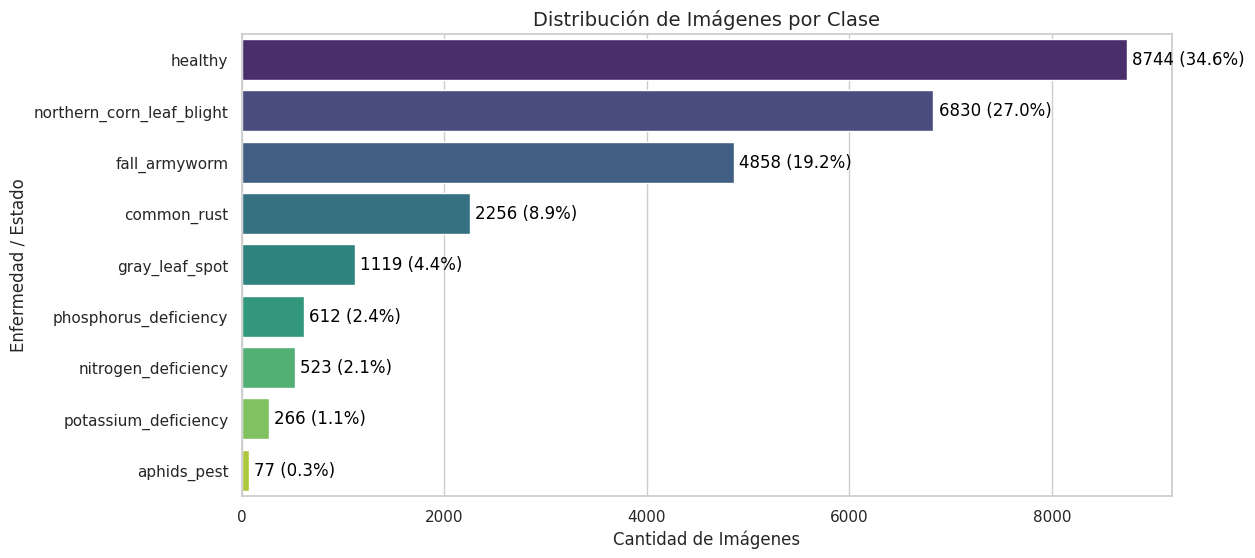

In [ ]:
conteos = {}
total_imagenes = 0

for clase in class_names:
    ruta_clase = os.path.join(DATA_DIR, clase)
    # Contamos todos los archivos, incluso si están dentro de subcarpetas (lab/real)
    cantidad = sum([len(files) for r, d, files in os.walk(ruta_clase)])
    conteos[clase] = cantidad
    total_imagenes += cantidad

df_conteos = pd.DataFrame(list(conteos.items()), columns=['Clase', 'Cantidad'])
df_conteos = df_conteos.sort_values(by='Cantidad', ascending=False)
df_conteos['Porcentaje'] = (df_conteos['Cantidad'] / total_imagenes) * 100

plt.figure(figsize=(12, 6))
grafico = sns.barplot(x='Cantidad', y='Clase', data=df_conteos, palette='viridis')

for index, row in enumerate(df_conteos.itertuples()):
    grafico.text(row.Cantidad + 50, index, f"{int(row.Cantidad)} ({row.Porcentaje:.1f}%)", color='black', va="center")

plt.title('Distribución de Imágenes por Clase', fontsize=14)
plt.xlabel('Cantidad de Imágenes')
plt.ylabel('Enfermedad / Estado')
plt.show()

## 1.3 Análisis de origen de las imágenes (Lab vs Real)
La procedencia de la imagen introduce un riesgo de *Data Leakage* o atajos de aprendizaje. Si una enfermedad específica tiene el 95% de sus imágenes tomadas en laboratorio con un fondo blanco, la red neuronal podría aprender a identificar el "fondo blanco" en lugar del patógeno real.

Analizando el origen de las imágenes (Lab vs Real)...


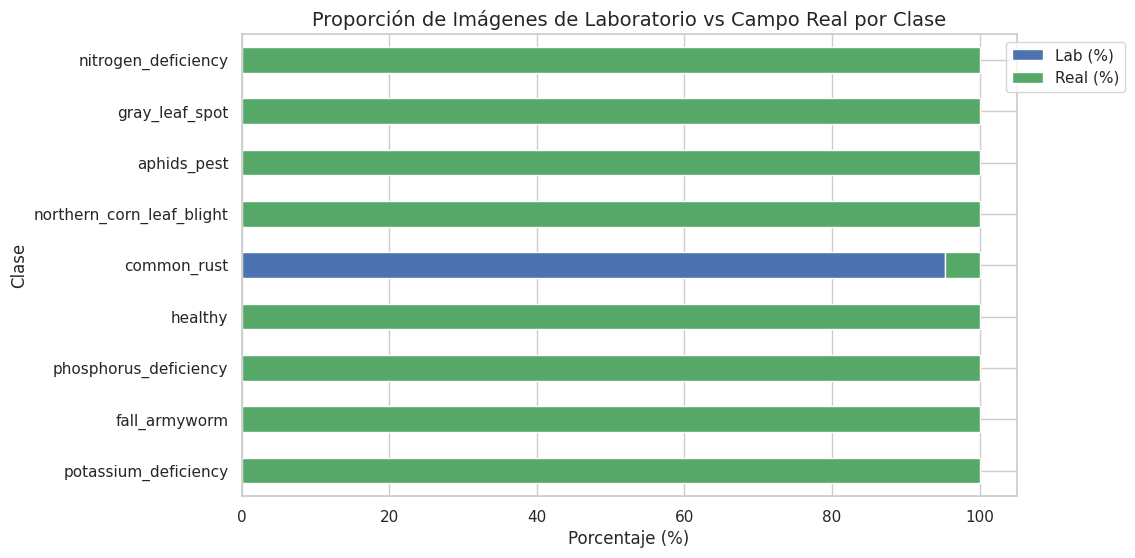

In [ ]:
print("Analizando el origen de las imágenes (Lab vs Real)...")

origen_datos = []

for clase in class_names:
    ruta_clase = os.path.join(DATA_DIR, clase)
    cant_lab = 0
    cant_real = 0

    # Recorremos todos los archivos de la clase
    for root, dirs, files in os.walk(ruta_clase):
        for file in files:
            nombre_archivo = file.lower()

            # Buscamos la etiqueta en el nombre del archivo o en la ruta
            if 'lab' in nombre_archivo or '/lab/' in root.lower():
                cant_lab += 1
            elif 'real' in nombre_archivo or '/real/' in root.lower():
                cant_real += 1
            else:
                # Si no especifica, asumimos que es una captura normal de campo (real)
                cant_real += 1

    total = cant_lab + cant_real

    # Solo agregamos si encontró imágenes para evitar el KeyError
    if total > 0:
        origen_datos.append({
            'Clase': clase,
            'Lab (%)': (cant_lab / total) * 100,
            'Real (%)': (cant_real / total) * 100
        })

# Ahora la lista sí tiene datos, podemos crear el DataFrame sin problemas
df_origen = pd.DataFrame(origen_datos).set_index('Clase')

df_origen.plot(kind='barh', stacked=True, figsize=(10, 6), color=['#4C72B0', '#55A868'])
plt.title('Proporción de Imágenes de Laboratorio vs Campo Real por Clase', fontsize=14)
plt.xlabel('Porcentaje (%)')
plt.ylabel('Clase')
plt.legend(loc='upper right', bbox_to_anchor=(1.15, 1))
plt.show()

## 1.4 Análisis de resolución y dimensiones
Las redes neuronales convolucionales requieren tensores de entrada con dimensiones fijas (en nuestro caso, 224x224 píxeles para MobileNetV3). Conocer las dimensiones originales nos ayuda a entender cuánta información se perderá o distorsionará durante el redimensionamiento (*resizing*).

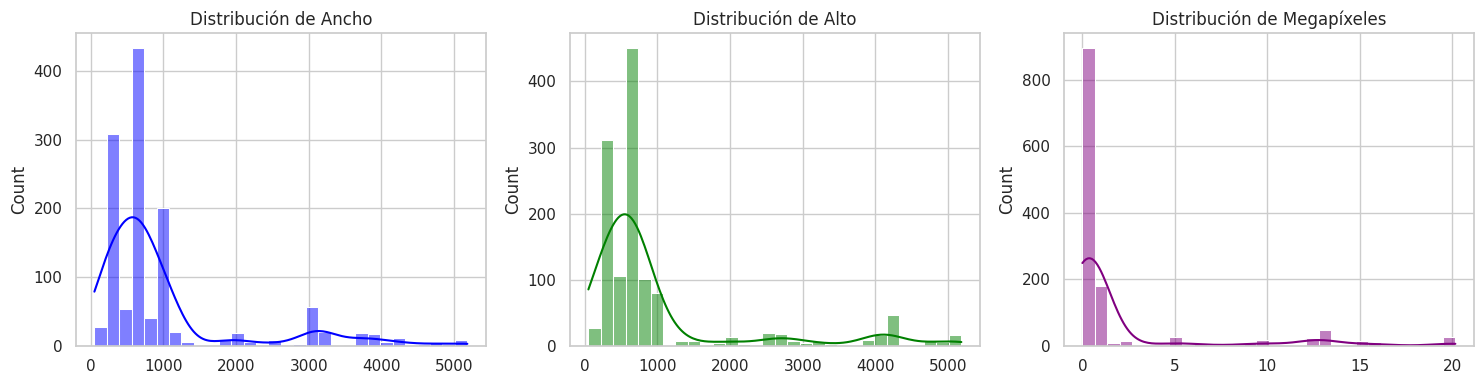

In [ ]:
# Muestreo para no saturar memoria
MUESTRA = 150
anchos, altos, megapixeles = [], [], []

for clase in class_names:
    rutas = []
    for root, dirs, files in os.walk(os.path.join(DATA_DIR, clase)):
        for file in files:
            rutas.append(os.path.join(root, file))

    muestra = random.sample(rutas, min(len(rutas), MUESTRA))

    for ruta in muestra:
        img = cv2.imread(ruta)
        if img is not None:
            h, w, _ = img.shape
            anchos.append(w)
            altos.append(h)
            megapixeles.append((w * h) / 1000000)

plt.figure(figsize=(15, 4))

plt.subplot(1, 3, 1)
sns.histplot(anchos, bins=30, kde=True, color='blue')
plt.title('Distribución de Ancho')

plt.subplot(1, 3, 2)
sns.histplot(altos, bins=30, kde=True, color='green')
plt.title('Distribución de Alto')

plt.subplot(1, 3, 3)
sns.histplot(megapixeles, bins=30, kde=True, color='purple')
plt.title('Distribución de Megapíxeles')

plt.tight_layout()
plt.show()

## 1.5 Análisis de calidad de imagen (Brillo y Desenfoque)
Se evaluó la exposición y nitidez de las imágenes. Para detectar imágenes borrosas, calculamos la varianza del Laplaciano; valores muy cercanos a cero indican falta de bordes detectables (desenfoque severo). El brillo medio nos indica si existen problemas de subexposición o sobreexposición severa en el dataset.

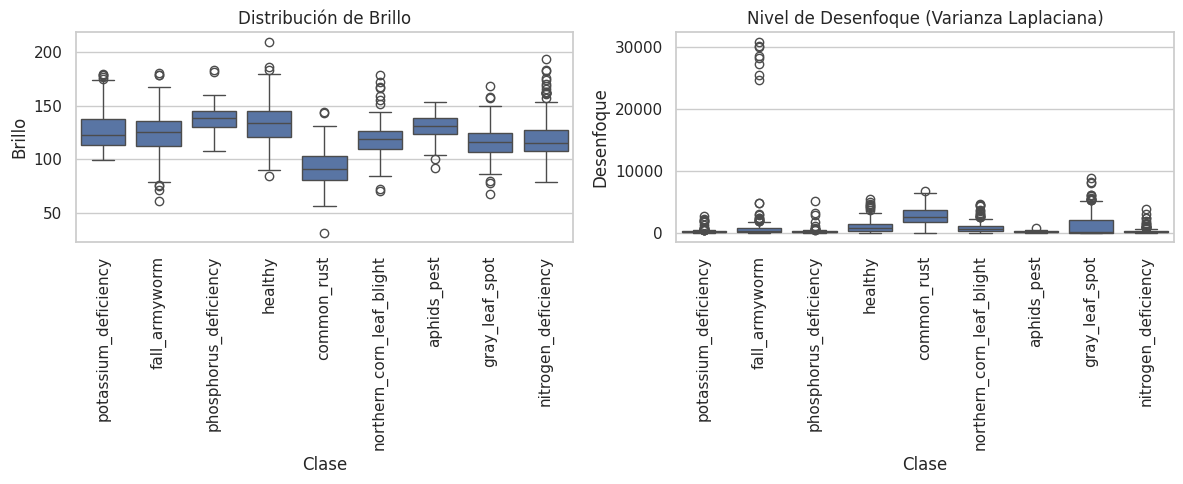

In [ ]:
calidad_datos = []

for clase in class_names:
    rutas = []
    for root, dirs, files in os.walk(os.path.join(DATA_DIR, clase)):
        for file in files:
            rutas.append(os.path.join(root, file))

    muestra = random.sample(rutas, min(len(rutas), MUESTRA))

    for ruta in muestra:
        img = cv2.imread(ruta)
        if img is not None:
            gris = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
            # Varianza del Laplaciano (Métrica de qué tan borrosa es)
            laplaciano_var = cv2.Laplacian(gris, cv2.CV_64F).var()
            brillo = np.mean(gris)

            calidad_datos.append({'Clase': clase, 'Desenfoque': laplaciano_var, 'Brillo': brillo})

df_calidad = pd.DataFrame(calidad_datos)

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
sns.boxplot(x='Clase', y='Brillo', data=df_calidad)
plt.xticks(rotation=90)
plt.title('Distribución de Brillo')

plt.subplot(1, 2, 2)
sns.boxplot(x='Clase', y='Desenfoque', data=df_calidad)
plt.xticks(rotation=90)
plt.title('Nivel de Desenfoque (Varianza Laplaciana)')

plt.tight_layout()
plt.show()

## 1.6 Detección de duplicados y limpieza
Antes del análisis, se ejecutó un proceso automatizado de limpieza de datos mediante el script `clean_corrupted_images.py`.
* **Metodología:** [Describe aquí si usaste comparación por Hash (pHash) o simplemente revisión de cabeceras corruptas].
* **Resultados:** Se eliminaron [Cantidad] imágenes corruptas o duplicadas que representaban un riesgo de *Data Leakage* entre los conjuntos de entrenamiento y prueba.

## 1.7 Identificación de posibles sesgos (Conclusión del EDA)
Basado en los gráficos anteriores, se detectaron los siguientes riesgos:
1. **[Escribe aquí tu conclusión del gráfico de clases, ej: El dataset está dominado por la clase Healthy, lo que requirió la implementación de pesos de clase en TensorFlow]**.
2. **[Escribe aquí tu conclusión del gráfico Lab vs Real, ej: La clase Common Rust muestra un alto porcentaje de fotos de laboratorio. El modelo de Data Augmentation debe ser agresivo con esta clase para evitar que la red memorice el fondo blanco]**.